In [1]:
# Imports and Config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

INPUT_CSV    = r"C:\Users\RF-LAB\Desktop\Pipeline\Features_DroneRF_labeled.csv"
MODEL_OUT    = r"C:\Users\RF-LAB\Desktop\Pipeline\drone_xgb_model.pkl"
RANDOM_STATE = 42
N_FOLDS      = 5

print('All imports OK')

All imports OK


In [2]:
# Load and Split Data
df = pd.read_csv(INPUT_CSV)

print(f'Total samples : {len(df)}')
print(f'Drone   (1)   : {(df["label"]==1).sum()}')
print(f'No-Drone(0)   : {(df["label"]==0).sum()}')

feature_cols = [c for c in df.columns if c != 'label']
X = df[feature_cols].values
y = df['label'].values

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f'\nTrain set : {len(X_train)} samples  (Drone={y_train.sum()}, No-Drone={(y_train==0).sum()})')
print(f'Test set  : {len(X_test)} samples  (Drone={y_test.sum()}, No-Drone={(y_test==0).sum()})')

Total samples : 454
Drone   (1)   : 372
No-Drone(0)   : 82

Train set : 363 samples  (Drone=297, No-Drone=66)
Test set  : 91 samples  (Drone=75, No-Drone=16)


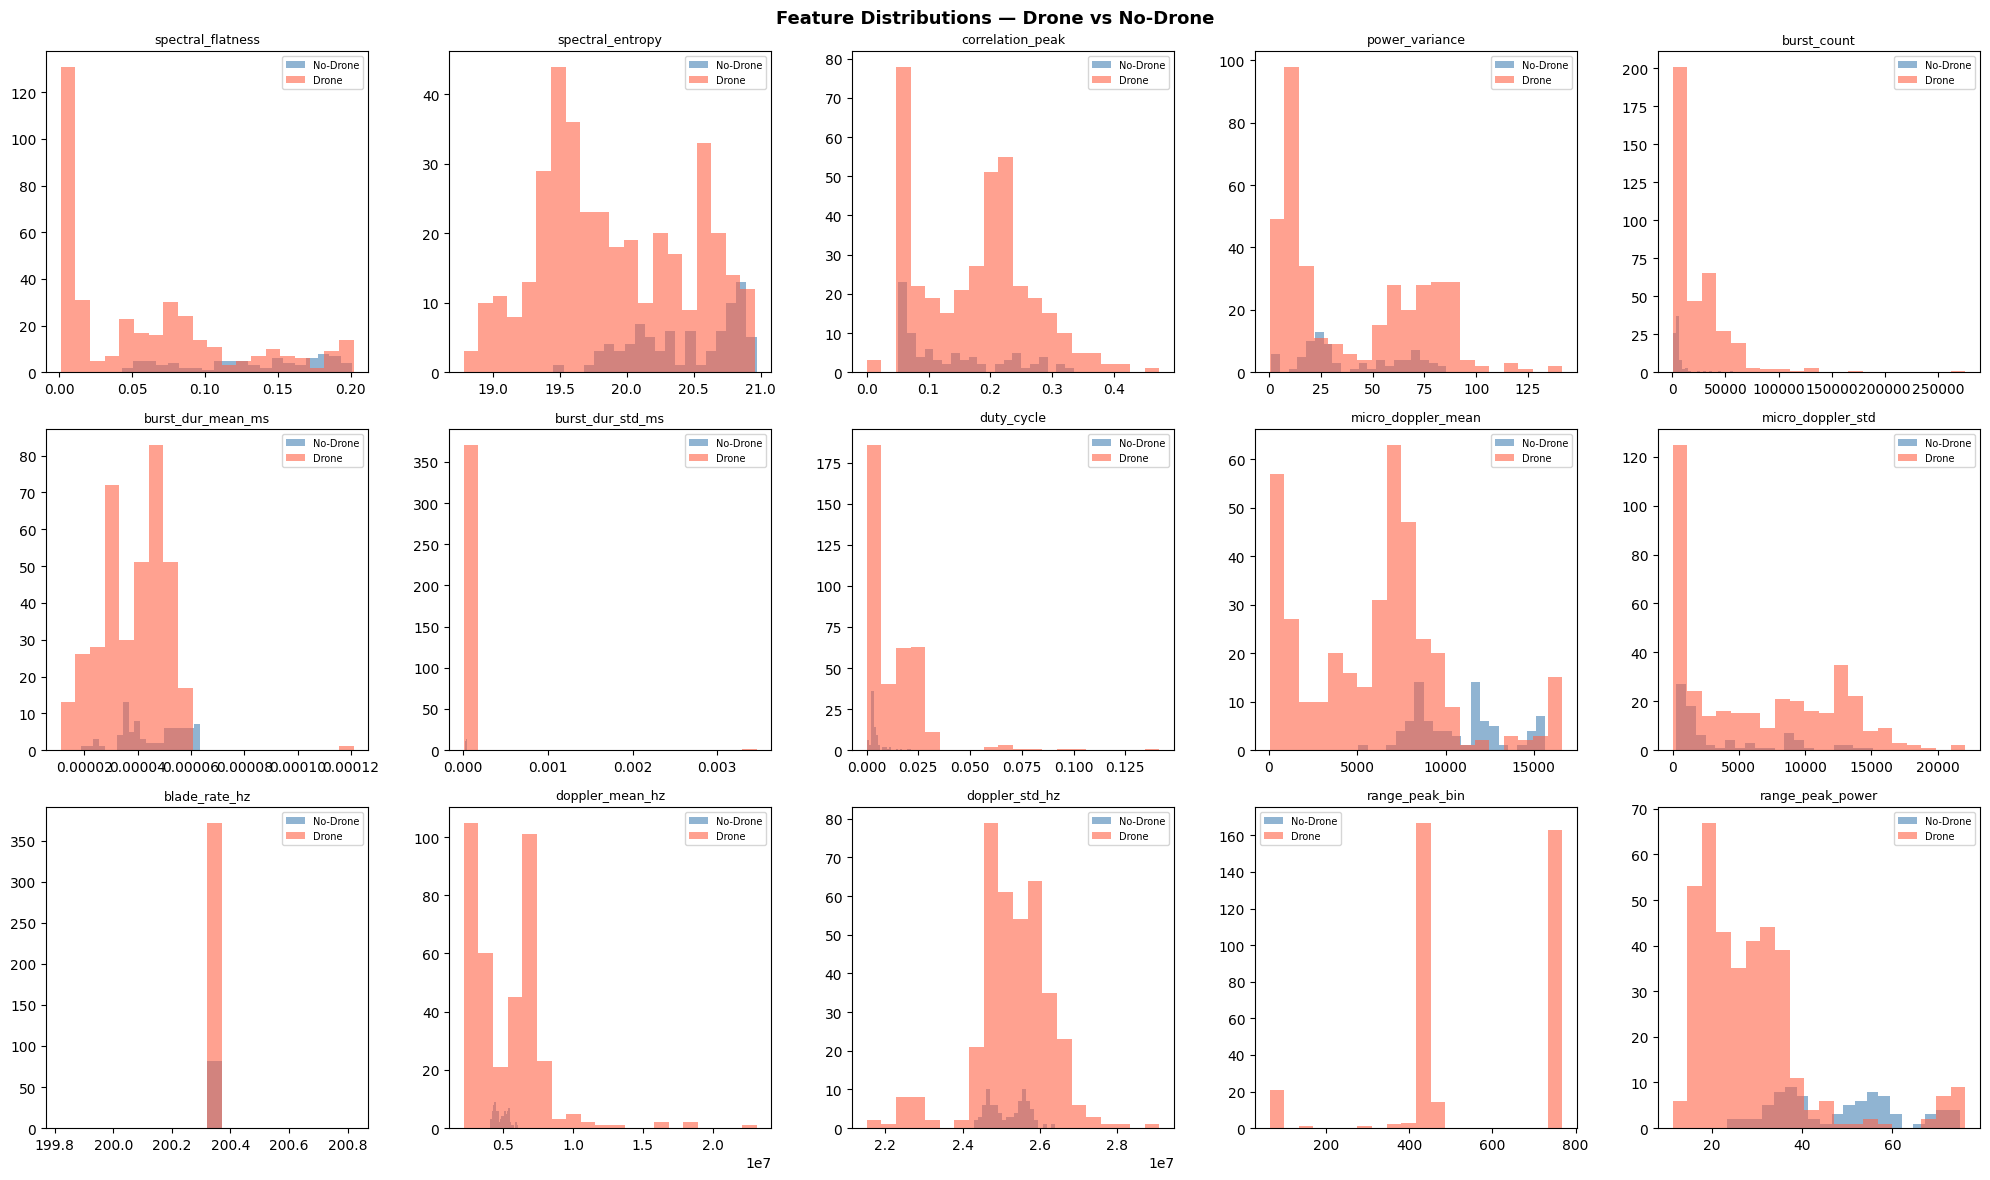

In [3]:
# Feature Distribution Plots
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, feat in enumerate(feature_cols):
    for label, color, name in [(0, 'steelblue', 'No-Drone'), (1, 'tomato', 'Drone')]:
        axes[i].hist(
            df.loc[df['label'] == label, feat],
            bins=20, alpha=0.6, color=color, label=name
        )
    axes[i].set_title(feat, fontsize=9)
    axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions — Drone vs No-Drone', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

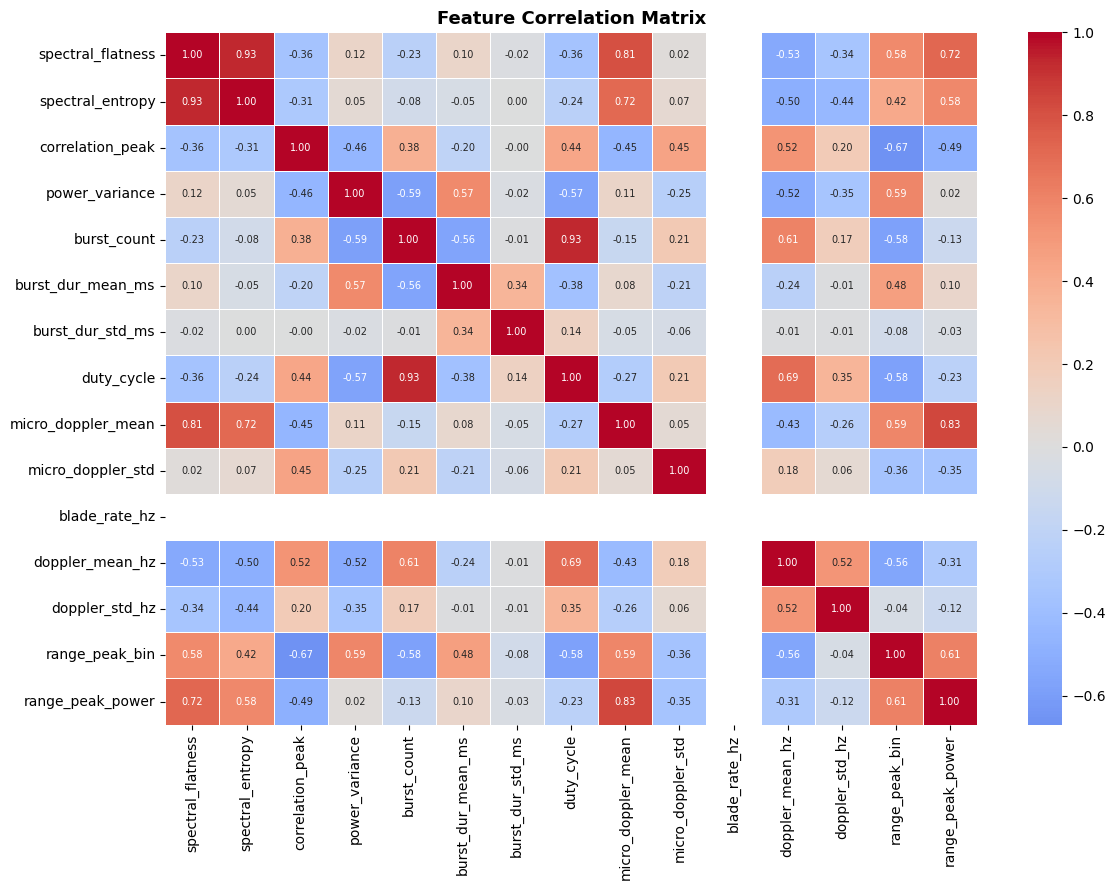

In [4]:
# Correlation Heatmap
plt.figure(figsize=(12, 9))
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# Train with stratified K-fold on training set
# Build pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(
        n_estimators     = 200,
        max_depth        = 4,
        learning_rate    = 0.1,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        eval_metric      = 'logloss',
        random_state     = RANDOM_STATE
    ))
])

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = cross_validate(
    pipeline, X_train, y_train,
    cv=cv, scoring=scoring, return_train_score=True
)

print(f'\n{"="*50}')
print(f'{"Cross-Validation Results (Train Set)":^50}')
print(f'{"="*50}')
for metric in scoring:
    val = cv_results[f'test_{metric}']
    print(f'  {metric:<12}: {val.mean():.4f}  (±{val.std():.4f})')
print(f'{"="*50}')


       Cross-Validation Results (Train Set)       
  accuracy    : 0.9917  (±0.0111)
  precision   : 0.9933  (±0.0082)
  recall      : 0.9966  (±0.0068)
  f1          : 0.9950  (±0.0068)
  roc_auc     : 0.9982  (±0.0037)


In [6]:
# Fit model on full training model
pipeline.fit(X_train, y_train)
print('Model trained on 80% train set.')

Model trained on 80% train set.


In [7]:
# Evaluate on held out test set
y_pred      = pipeline.predict(X_test)
y_pred_prob = pipeline.predict_proba(X_test)[:, 1]

print('=== HELD-OUT TEST SET RESULTS ===')
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision : {precision_score(y_test, y_pred):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred):.4f}')
print(f'F1        : {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC   : {roc_auc_score(y_test, y_pred_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No-Drone', 'Drone']))

=== HELD-OUT TEST SET RESULTS ===
Accuracy  : 0.9780
Precision : 0.9740
Recall    : 1.0000
F1        : 0.9868
ROC-AUC   : 0.9983

              precision    recall  f1-score   support

    No-Drone       1.00      0.88      0.93        16
       Drone       0.97      1.00      0.99        75

    accuracy                           0.98        91
   macro avg       0.99      0.94      0.96        91
weighted avg       0.98      0.98      0.98        91



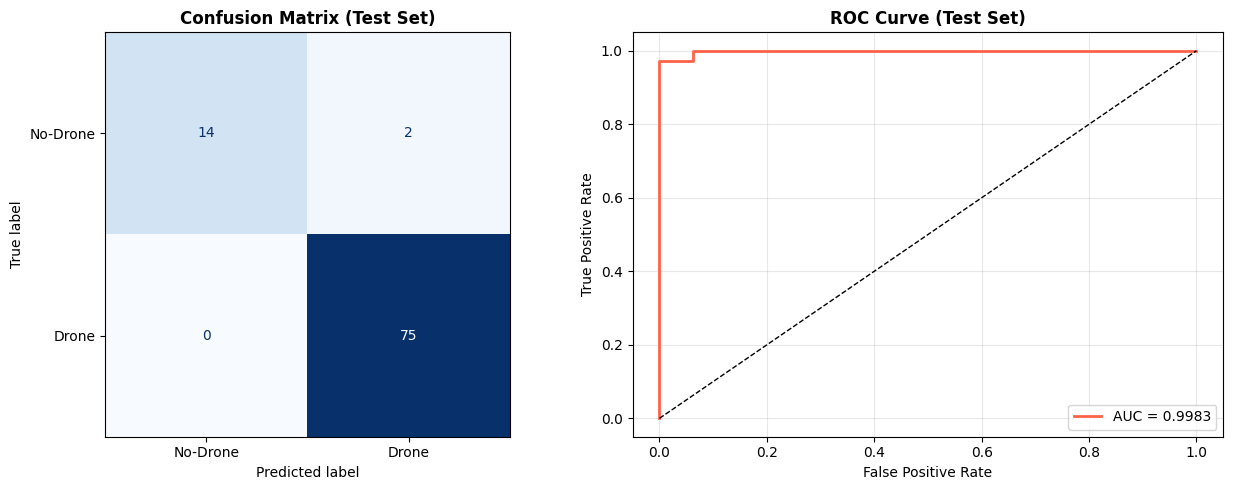

In [8]:
# Confusion matrix and ROC curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No-Drone', 'Drone']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix (Test Set)', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='tomato', lw=2, label=f'AUC = {auc_score:.4f}')
axes[1].plot([0,1],[0,1],'k--',lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Test Set)', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

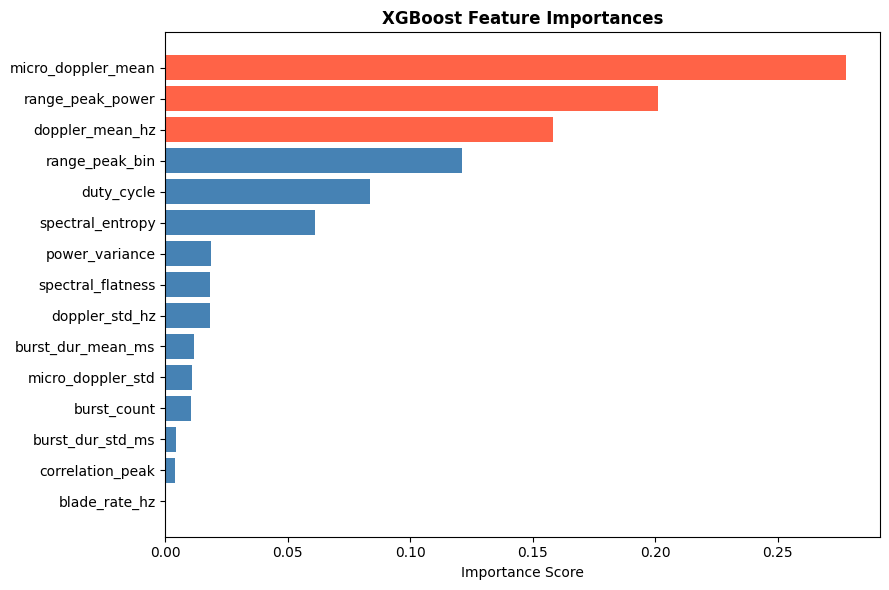


Top 5 most important features:
               feature  importance
8   micro_doppler_mean    0.277940
14    range_peak_power    0.201065
11     doppler_mean_hz    0.158476
13      range_peak_bin    0.121226
7           duty_cycle    0.083466


In [9]:
# Feature Importance
importances = pipeline.named_steps['clf'].feature_importances_
feat_imp_df = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': importances
}).sort_values('importance', ascending=True)

plt.figure(figsize=(9, 6))
colors = ['tomato' if i >= len(feat_imp_df)-3 else 'steelblue'
          for i in range(len(feat_imp_df))]
plt.barh(feat_imp_df['feature'], feat_imp_df['importance'], color=colors)
plt.xlabel('Importance Score')
plt.title('XGBoost Feature Importances', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(feat_imp_df.sort_values('importance', ascending=False).head())

In [10]:
# Save model
joblib.dump(pipeline, MODEL_OUT)
print(f'Model saved → {MODEL_OUT}')

Model saved → C:\Users\RF-LAB\Desktop\Pipeline\drone_xgb_model.pkl


In [ ]:
import os
from scipy.signal import find_peaks

# ── Set your path here ────────────────────────────────────
# For a single file:  INPUT_PATH = r"C:\path\to\file.npy"
# For a folder:       INPUT_PATH = r"C:\path\to\folder"
INPUT_PATH = r"C:\Users\RF-LAB\Desktop\Pipeline\New_Test_Data_Noise_processed\00000L_13_processed.npy"
# ─────────────────────────────────────────────────────────

fs           = 100e6
BURST_THRESH = 0.3
NPERSEG      = 1024
HOP          = 512
MAX_SAMPLES  = 5_000_000

def spectral_flatness(power_spec):
    ps = np.abs(power_spec) + 1e-12
    return float(np.exp(np.mean(np.log(ps))) / np.mean(ps))

def spectral_entropy(power_spec):
    ps = np.abs(power_spec) + 1e-12
    ps_norm = ps / np.sum(ps)
    return float(-np.sum(ps_norm * np.log2(ps_norm)))

def correlation_peak(z):
    seg = z[:1_000_000]; N = len(seg)
    Z = np.fft.fft(seg, n=2*N)
    acorr = np.fft.ifft(Z * np.conj(Z)).real[:N]
    acorr /= (acorr[0] + 1e-12)
    peaks, _ = find_peaks(acorr[1:], height=0.05)
    return float(acorr[peaks[0] + 1]) if len(peaks) > 0 else 0.0

def power_variance(z, window_size=1024):
    power = np.abs(z) ** 2
    n_blocks = len(power) // window_size
    if n_blocks == 0:
        return float(np.var(power))
    blocks = power[:n_blocks * window_size].reshape(n_blocks, window_size)
    return float(np.var(np.mean(blocks, axis=1)))

def burst_features(z, fs, threshold=BURST_THRESH):
    amplitude = np.abs(z)
    active = (amplitude > threshold * np.max(amplitude)).astype(np.int32)
    diff = np.diff(active)
    starts, ends = np.where(diff == 1)[0], np.where(diff == -1)[0]
    duty = float(np.mean(active.astype(np.float32)))
    if len(starts) == 0 or len(ends) == 0: return 0, 0.0, 0.0, duty
    if ends[0] < starts[0]: ends = ends[1:]
    if len(starts) > len(ends): starts = starts[:len(ends)]
    if len(starts) == 0: return 0, 0.0, 0.0, duty
    durations_ms = (ends - starts) / fs * 1000.0
    return int(len(durations_ms)), float(np.mean(durations_ms)), float(np.std(durations_ms)), duty

def micro_doppler(z, fs, nperseg=NPERSEG, hop=HOP):
    seg = z[:500_000]
    window = np.hanning(nperseg).astype(np.float32)
    n_steps = (len(seg) - nperseg) // hop + 1
    if n_steps <= 0: return 0.0, 0.0, 0.0
    energy = np.array([np.sum(np.abs(np.fft.fft(seg[i*hop:i*hop+nperseg] * window))) for i in range(n_steps)])
    freqs = np.fft.rfftfreq(len(energy), d=hop/fs)
    mask = (freqs >= 10) & (freqs <= 300)
    blade = float(freqs[mask][np.argmax(np.abs(np.fft.rfft(energy))[mask])]) if np.any(mask) else 0.0
    return float(np.mean(energy)), float(np.std(energy)), blade

def doppler_shift(z, fs):
    inst_freq = np.diff(np.unwrap(np.angle(z))) / (2.0 * np.pi) * fs
    return float(np.mean(inst_freq)), float(np.std(inst_freq))

def range_fft(z, nperseg=NPERSEG):
    n_seg = len(z) // nperseg
    if n_seg == 0: return 0.0, 0.0
    window = np.hanning(nperseg).astype(np.float32)
    avg = np.mean([np.abs(np.fft.fft(z[i*nperseg:(i+1)*nperseg] * window)) for i in range(n_seg)], axis=0)
    return float(np.argmax(avg)), float(avg[int(np.argmax(avg))])

def extract_features(filepath):
    data = np.load(filepath)
    if data.ndim == 2:
        I, Q = data[0].astype(np.float32), data[1].astype(np.float32)
    elif np.iscomplexobj(data):
        I, Q = data.real.astype(np.float32), data.imag.astype(np.float32)
    else:
        raise ValueError(f"Unexpected shape {data.shape}, dtype {data.dtype}")
    N = len(I)
    if N > MAX_SAMPLES:
        idx = np.linspace(0, N-1, MAX_SAMPLES, dtype=np.int64)
        I, Q = I[idx], Q[idx]
    z = I + 1j * Q
    power_spec = np.abs(np.fft.fft(z * np.hanning(len(z)).astype(np.float32))) ** 2
    sf  = spectral_flatness(power_spec)
    se  = spectral_entropy(power_spec)
    cp_ = correlation_peak(z)
    pv  = power_variance(z)
    bc, bd_mean, bd_std, dc = burst_features(z, fs)
    md_mean, md_std, blade  = micro_doppler(z, fs)
    dop_mean, dop_std       = doppler_shift(z, fs)
    r_bin, r_pwr            = range_fft(z)
    return [sf, se, cp_, pv, bc, bd_mean, bd_std, dc,
            md_mean, md_std, blade, dop_mean, dop_std, r_bin, r_pwr]

# ── Load the already-trained model ────────────────────────
loaded_pipeline = joblib.load(MODEL_OUT)
label_map = {0: 'No-Drone', 1: 'Drone'}

# ── Resolve single file or folder ─────────────────────────
if os.path.isfile(INPUT_PATH):
    npy_files = [INPUT_PATH]
elif os.path.isdir(INPUT_PATH):
    npy_files = sorted([
        os.path.join(INPUT_PATH, f)
        for f in os.listdir(INPUT_PATH) if f.endswith('.npy')
    ])
else:
    raise ValueError(f"INPUT_PATH does not exist: {INPUT_PATH}")

print(f"Found {len(npy_files)} file(s). Running inference...\n")
results = []

for fp in npy_files:
    fname = os.path.basename(fp)
    try:
        features = extract_features(fp)
        pred     = loaded_pipeline.predict([features])[0]
        proba    = loaded_pipeline.predict_proba([features])[0]
        results.append({
            'file'         : fname,
            'prediction'   : label_map[pred],
            'prob_no_drone': round(proba[0], 4),
            'prob_drone'   : round(proba[1], 4),
        })
        print(f"  {'[DRONE]   ' if pred==1 else '[NO-DRONE]'}  {fname}  "
              f"(Drone={proba[1]:.4f}, No-Drone={proba[0]:.4f})")
    except Exception as e:
        print(f"  [ERROR]    {fname}  →  {e}")
        results.append({'file': fname, 'prediction': 'ERROR',
                        'prob_no_drone': None, 'prob_drone': None})

results_df = pd.DataFrame(results)
print(f"\n{'='*55}")
print(f"  Drone: {(results_df['prediction']=='Drone').sum()}  |  "
      f"No-Drone: {(results_df['prediction']=='No-Drone').sum()}  |  "
      f"Errors: {(results_df['prediction']=='ERROR').sum()}")
print(f"{'='*55}")
display(results_df)

results_df.to_csv("inference_results.csv", index=False)
print("\nSaved → inference_results.csv")

Found 1 file(s). Running inference...

  [DRONE]     sunofdm_O2_mcs2_g0.0dB_att22dB_freq864.0MHz_4_processed.npy  (Drone=0.9987, No-Drone=0.0013)

  Drone: 1  |  No-Drone: 0  |  Errors: 0


,file,prediction,prob_no_drone,prob_drone
0,sunofdm_O2_mcs2_g0.0dB_att22dB_freq864.0MHz_4_...,Drone,0.0013,0.9987



Saved → inference_results.csv
